In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [72]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [17]:
df = pd.read_csv('titanic.csv', usecols=['Survived','Age','SibSp','Parch','Fare'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Parch     891 non-null    int64  
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [19]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

<Axes: xlabel='Fare', ylabel='Density'>

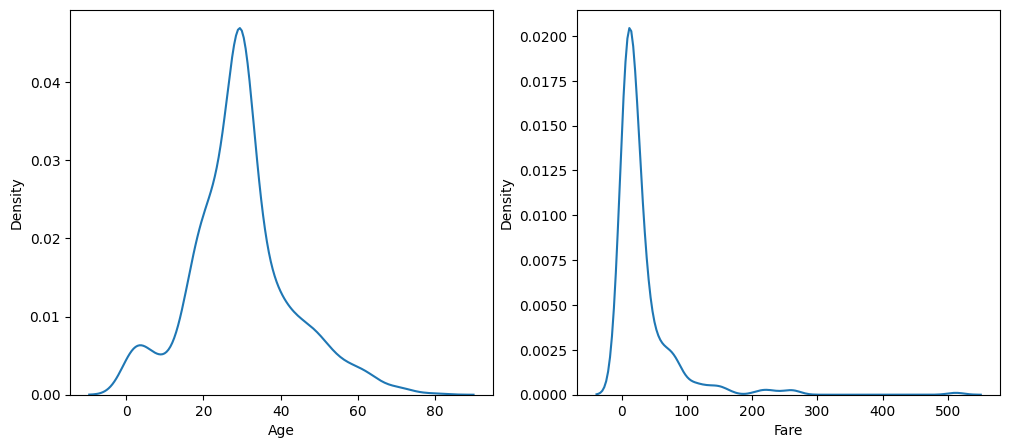

In [36]:
fig, axs = plt.subplots(figsize = (12,5),ncols=2 )
sns.kdeplot(data=df, x='Age',ax = axs[0])
sns.kdeplot(data=df, x='Fare',ax = axs[1])

In [37]:
from sklearn.preprocessing import FunctionTransformer

In [41]:
ft = FunctionTransformer(func = np.log1p)
ft

,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


In [47]:
new_fare = ft.fit_transform(df['Fare'])

Text(0.5, 1.0, 'Old Fare')

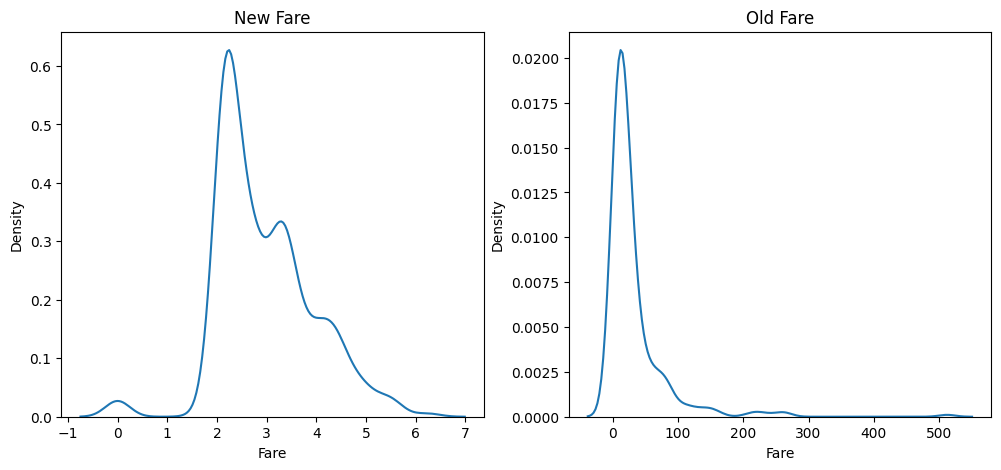

In [51]:
fig, axs = plt.subplots(figsize = (12,5),ncols=2 )
sns.kdeplot(new_fare,ax = axs[0])
axs[0].set_title('New Fare')
sns.kdeplot(data=df, x='Fare',ax = axs[1])
axs[1].set_title('Old Fare')

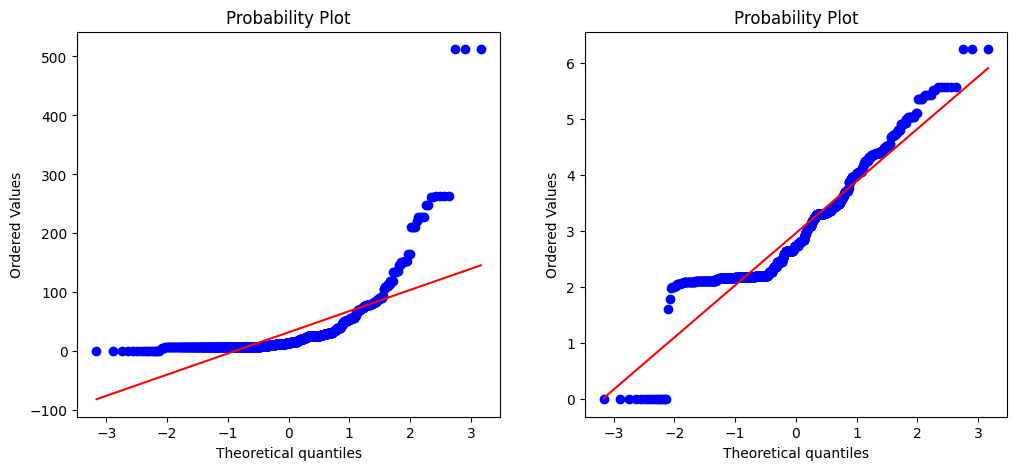

In [130]:
plt.figure(figsize=(12,5))
plt.subplot(121)
stats.probplot(df['Fare'], dist="norm", plot=plt);
plt.subplot(122)
stats.probplot(new_fare, dist="norm", plot=plt);

In [163]:
def apply_transform(transform, df):
    X = df.iloc[:,1:]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('Transform',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    # transform whole X
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression(max_iter=1000) # else it will run out of iteration and throw warning as it already did in this dataset
    clf2 = DecisionTreeClassifier()
    
    X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=11, test_size=0.2)
    # Accuracy without transform:
    clf.fit(X_train,y_train)
    clf2.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    y_pred2 = clf2.predict(X_test)
    
    print("Accuracy (No Transform) with Train Test Split")
    print("Accuracy LR",accuracy_score(y_test,y_pred))
    print("Accuracy DT",accuracy_score(y_test,y_pred2))
    print()
    
    # Transform X_test and X_train
    X_train_transformed = trf.fit_transform(X_train)
    X_test_transformed = trf.transform(X_test)

    clf.fit(X_train_transformed,y_train)
    clf2.fit(X_train_transformed,y_train)
    # Make Prediction (Splitted data)
    y_pred = clf.predict(X_test_transformed)
    y_pred2 = clf2.predict(X_test_transformed)

    print("Accuracy with Train Test Split")
    print("Accuracy LR",accuracy_score(y_test,y_pred))
    print("Accuracy DT",accuracy_score(y_test,y_pred2))

    print()
    print("Cross Val Accuracy :")
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    print("Accuracy",np.mean(cross_val_score(clf2,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,12))

    plt.subplot(421)
    stats.probplot(X['Fare'], dist="norm", plot=plt);
    plt.title('Fare Before Transform (whole)')

    plt.subplot(422)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt);
    plt.title('Fare After Transform (whole)')

    plt.subplot(423)
    stats.probplot(X_train['Fare'], dist="norm", plot=plt);
    plt.title('Fare Before Transform (Train Test)')

    plt.subplot(424)
    stats.probplot(X_train_transformed[:,0], dist="norm", plot=plt);
    plt.title('Fare After Transform (Train Test)')

    plt.subplot(425)
    stats.probplot(X['Age'], dist="norm", plot=plt);
    plt.title('Age Before Transform (whole)')

    plt.subplot(426)
    stats.probplot(X_trans[:,1], dist="norm", plot=plt);
    plt.title('Age After Transform (whole)')

    plt.subplot(427)
    stats.probplot(X_train['Age'], dist="norm", plot=plt);
    plt.title('Age Before Transform (Train Test)')

    plt.subplot(428)
    stats.probplot(X_train_transformed[:,1], dist="norm", plot=plt);
    plt.title('Age After Transform (Train Test)')

    plt.tight_layout()

    plt.show()
    

# Log Transformer

Accuracy (No Transform) with Train Test Split
Accuracy LR 0.7541899441340782
Accuracy DT 0.664804469273743

Accuracy with Train Test Split
Accuracy LR 0.7653631284916201
Accuracy DT 0.6703910614525139

Cross Val Accuracy :
Accuracy 0.7004119850187266
Accuracy 0.6487016229712859


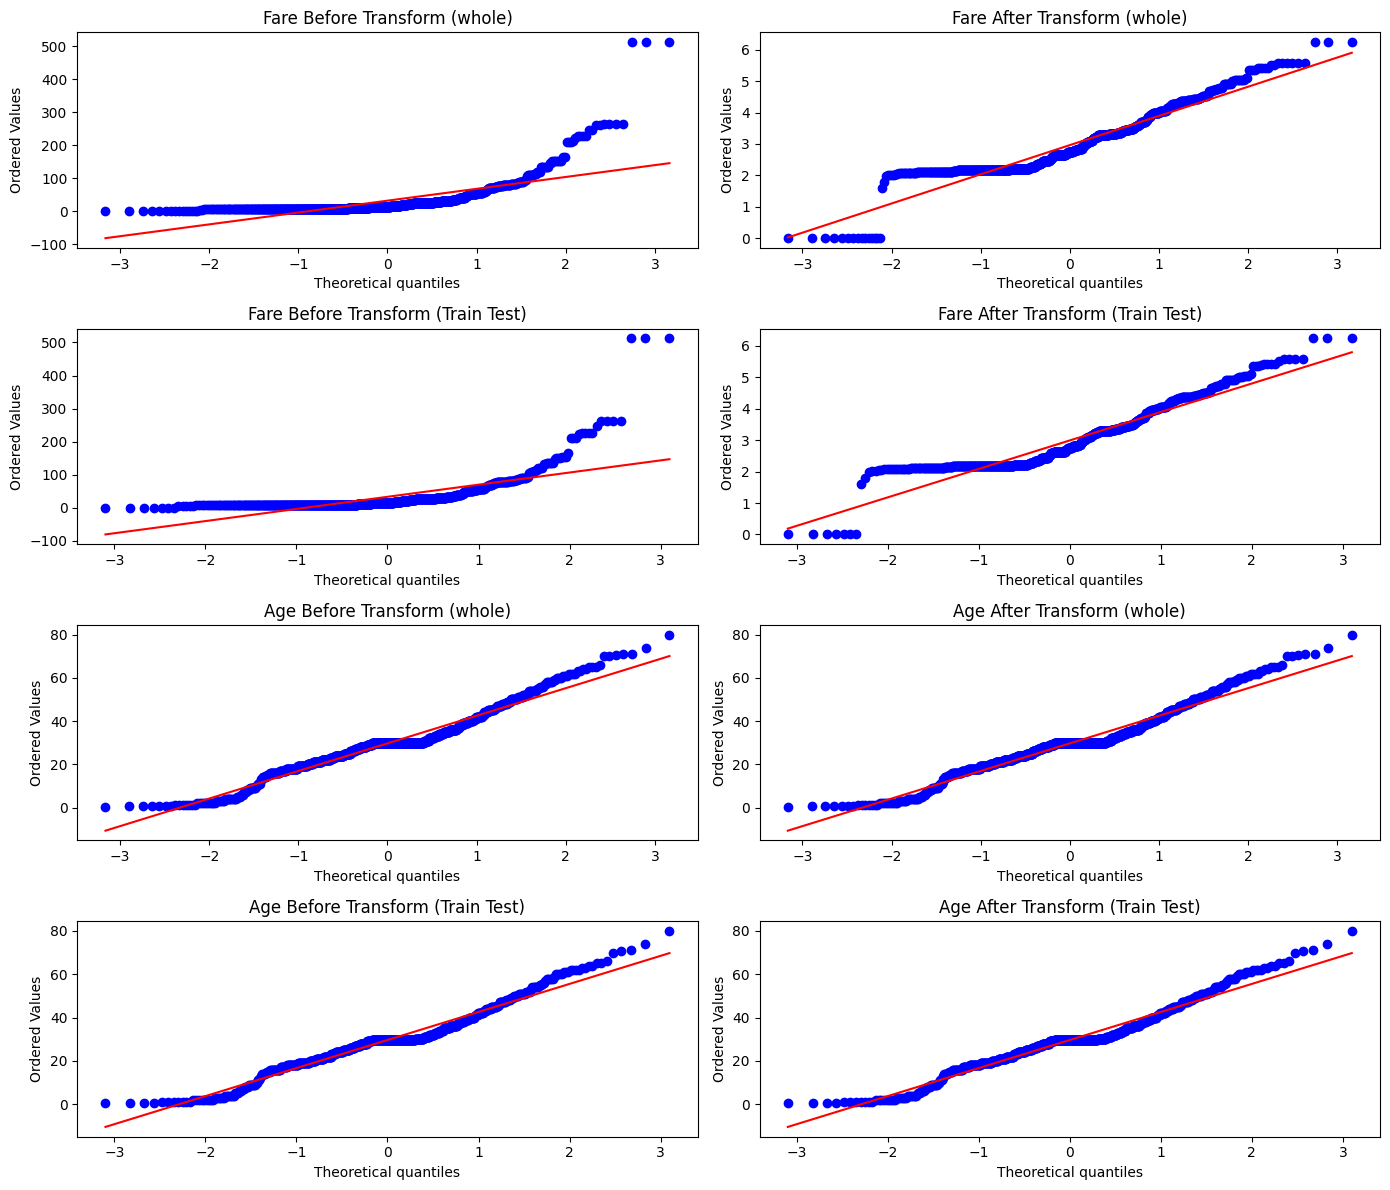

In [164]:
apply_transform(np.log1p,df)

# Reciprocal Transform(Inverts the distribution)

Accuracy (No Transform) with Train Test Split
Accuracy LR 0.7541899441340782
Accuracy DT 0.664804469273743

Accuracy with Train Test Split
Accuracy LR 0.6759776536312849
Accuracy DT 0.6815642458100558

Cross Val Accuracy :
Accuracy 0.6487265917602996
Accuracy 0.6464544319600499


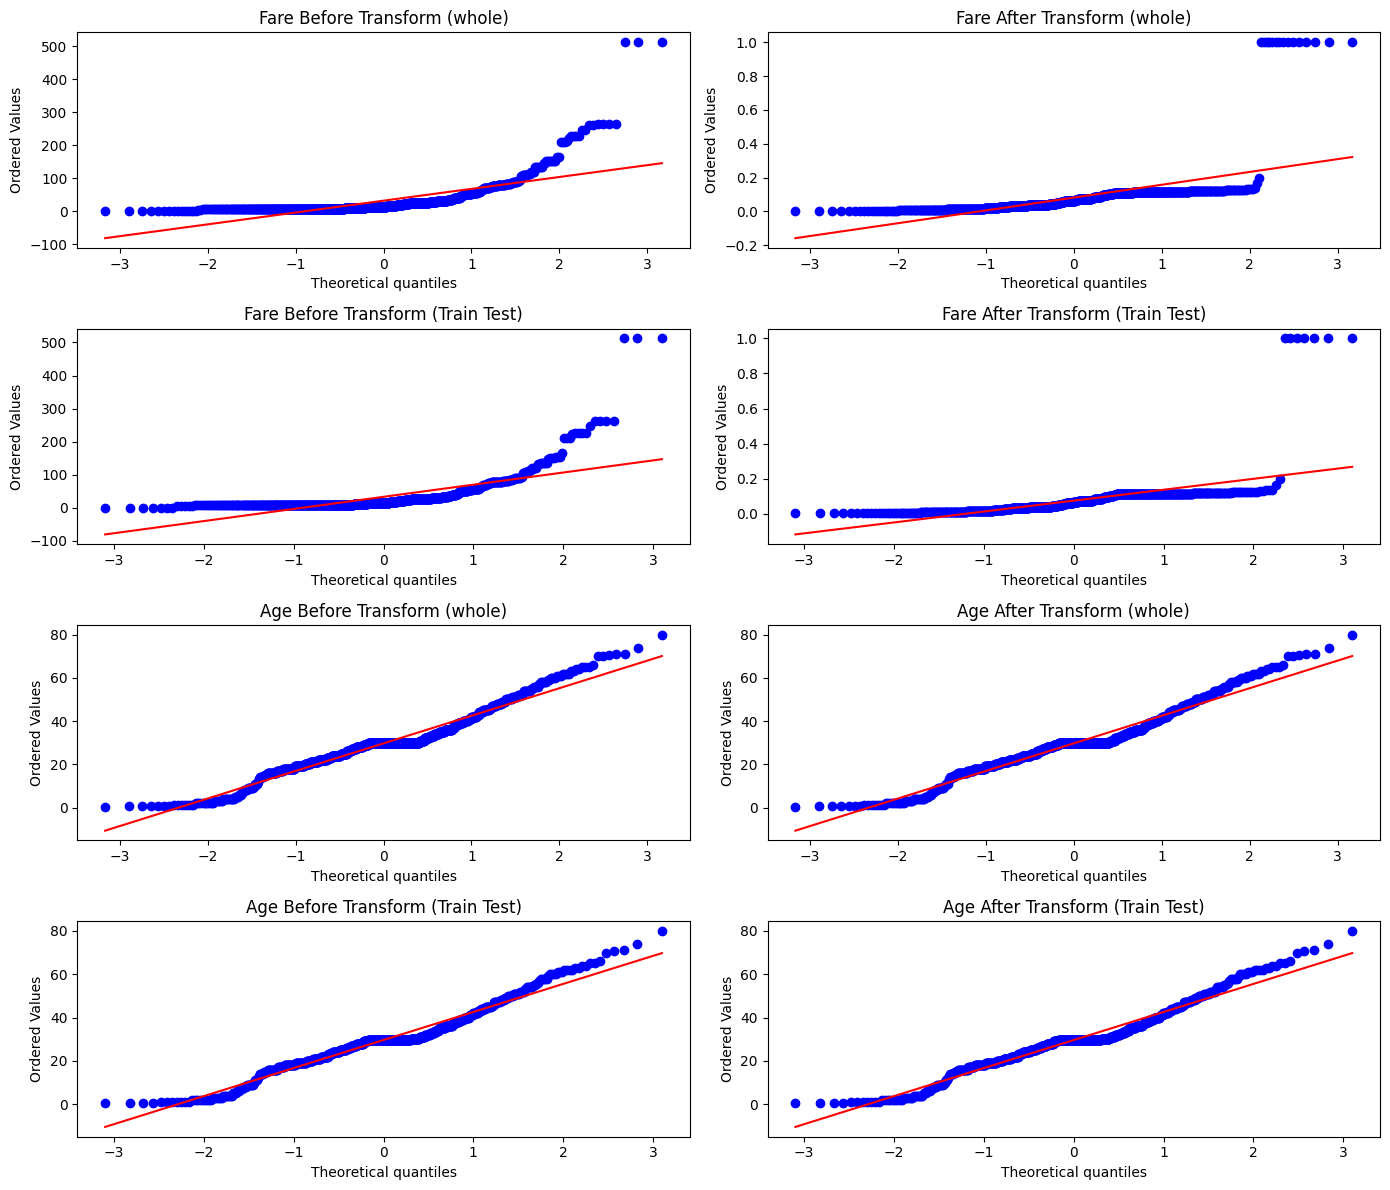

In [165]:
apply_transform(lambda x: 1 / (x + 1), df)

# Square Root Transform

Accuracy (No Transform) with Train Test Split
Accuracy LR 0.7541899441340782
Accuracy DT 0.664804469273743

Accuracy with Train Test Split
Accuracy LR 0.7653631284916201
Accuracy DT 0.6703910614525139

Cross Val Accuracy :
Accuracy 0.703732833957553
Accuracy 0.6430961298377029


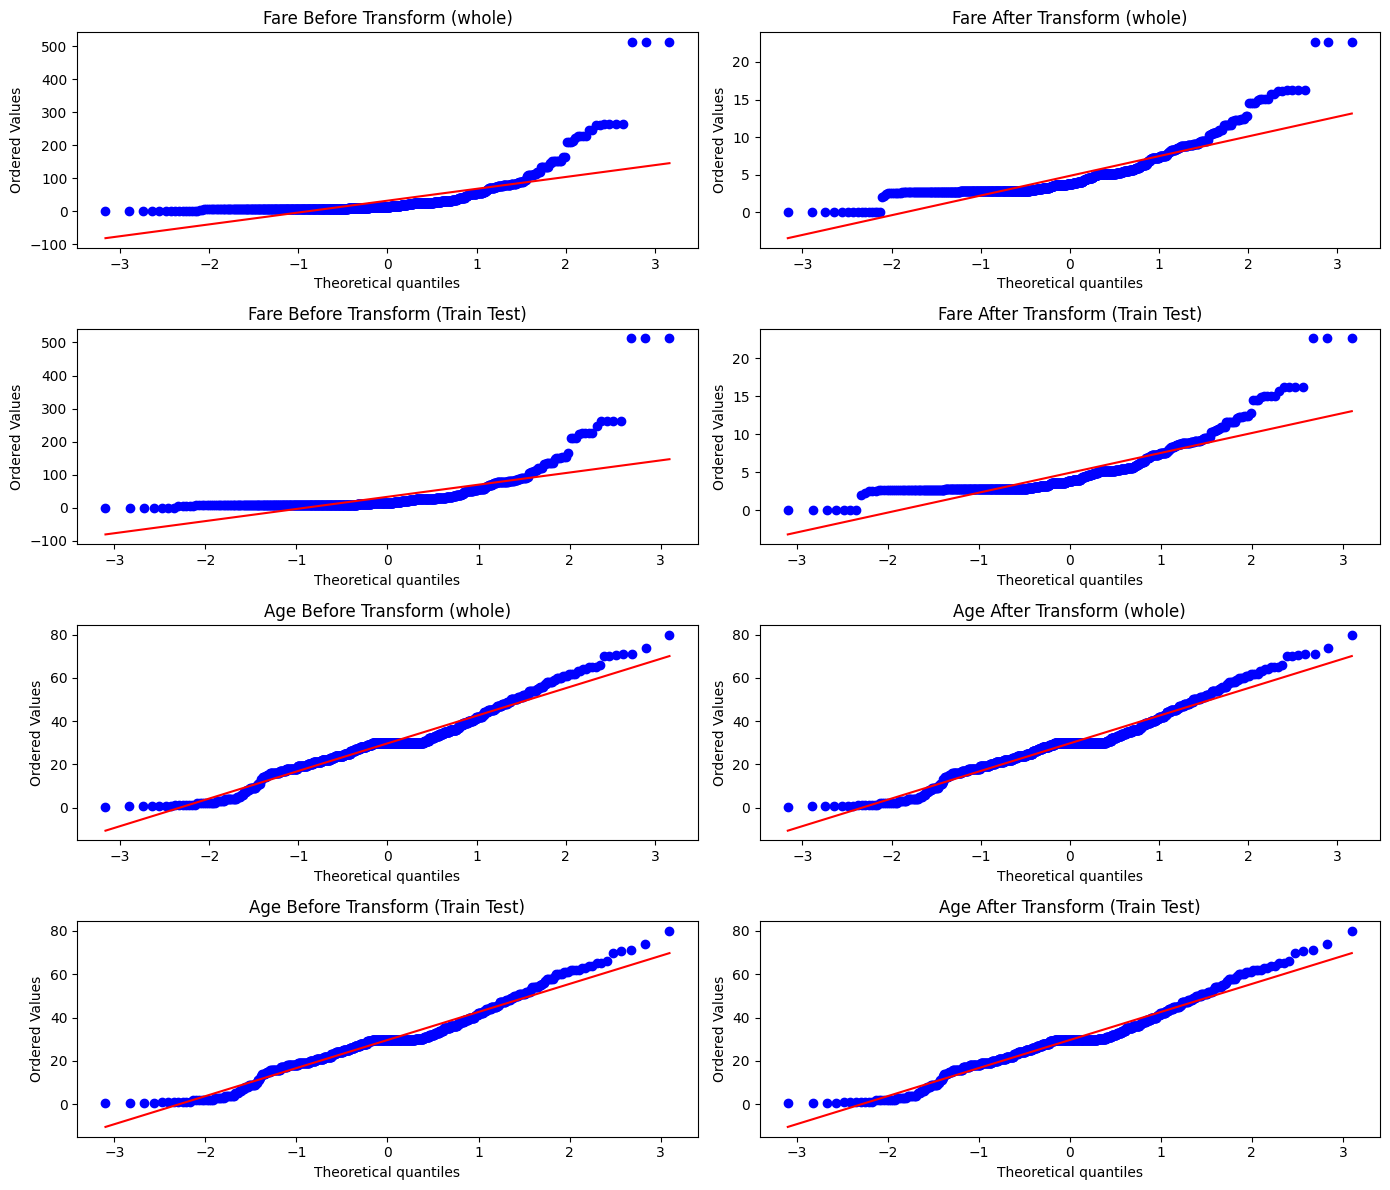

In [166]:
apply_transform(np.sqrt, df)

# Square Power Transform

Accuracy (No Transform) with Train Test Split
Accuracy LR 0.7541899441340782
Accuracy DT 0.664804469273743

Accuracy with Train Test Split
Accuracy LR 0.6983240223463687
Accuracy DT 0.664804469273743

Cross Val Accuracy :
Accuracy 0.6543445692883896
Accuracy 0.64083645443196


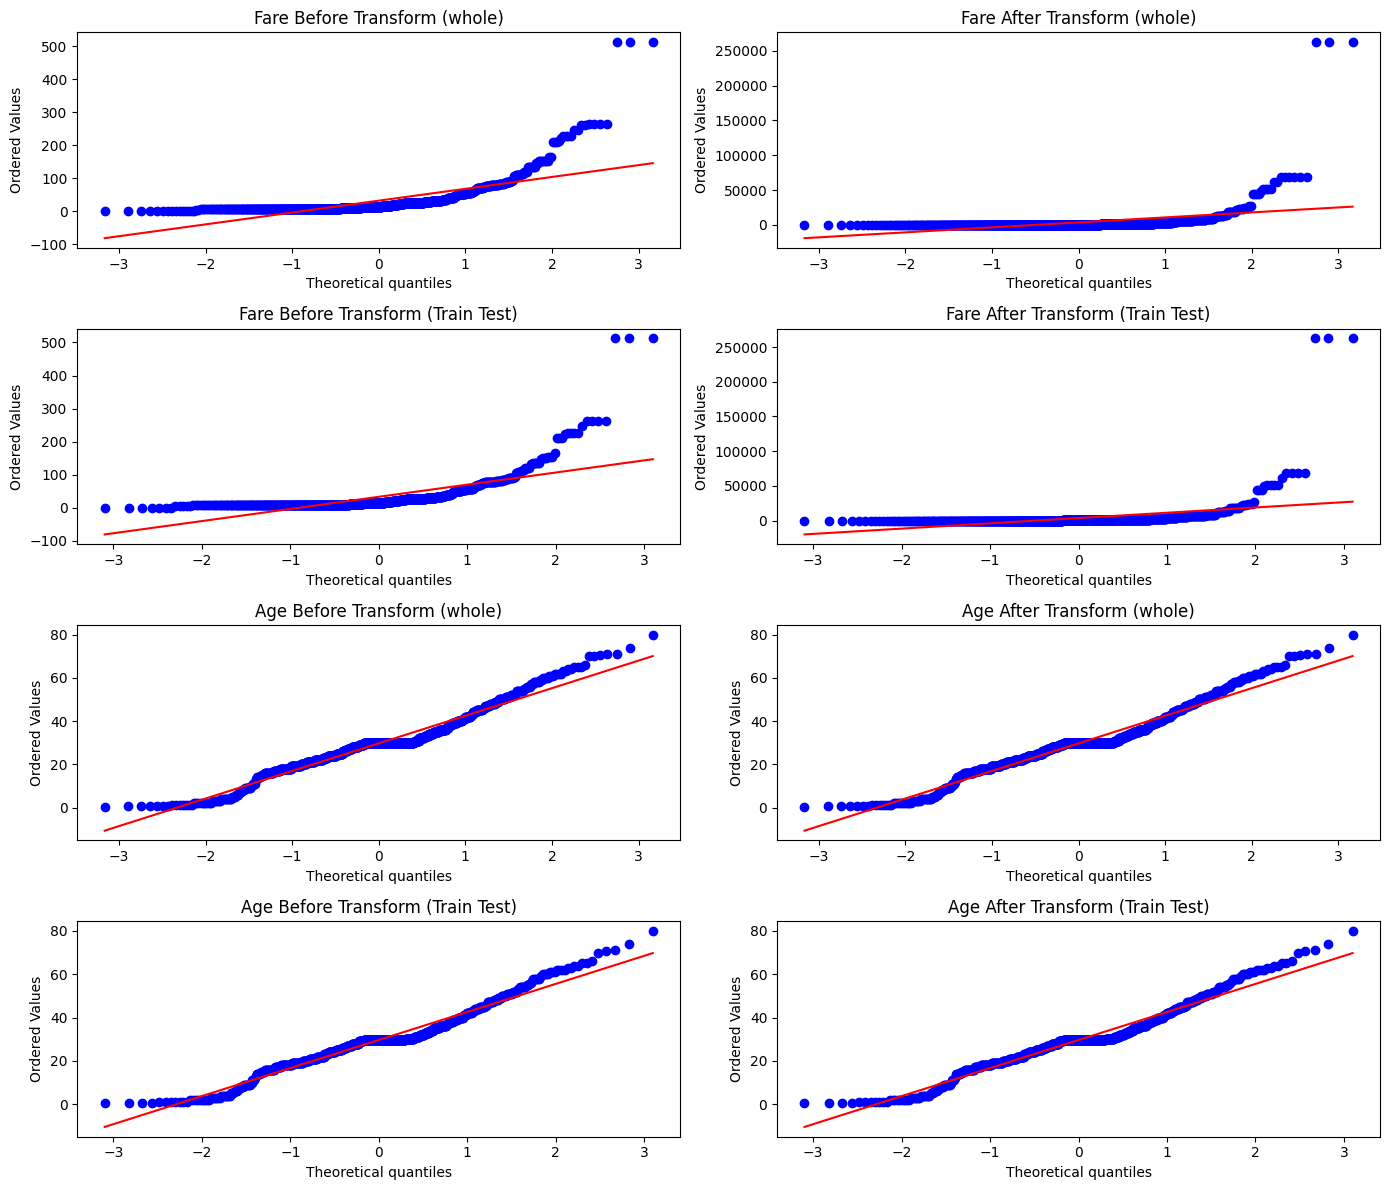

In [167]:
apply_transform(lambda x: x**2, df)

In [168]:
# Sin transform

Accuracy (No Transform) with Train Test Split
Accuracy LR 0.7541899441340782
Accuracy DT 0.6703910614525139

Accuracy with Train Test Split
Accuracy LR 0.6759776536312849
Accuracy DT 0.6536312849162011

Cross Val Accuracy :
Accuracy 0.6374781523096129
Accuracy 0.6587640449438202


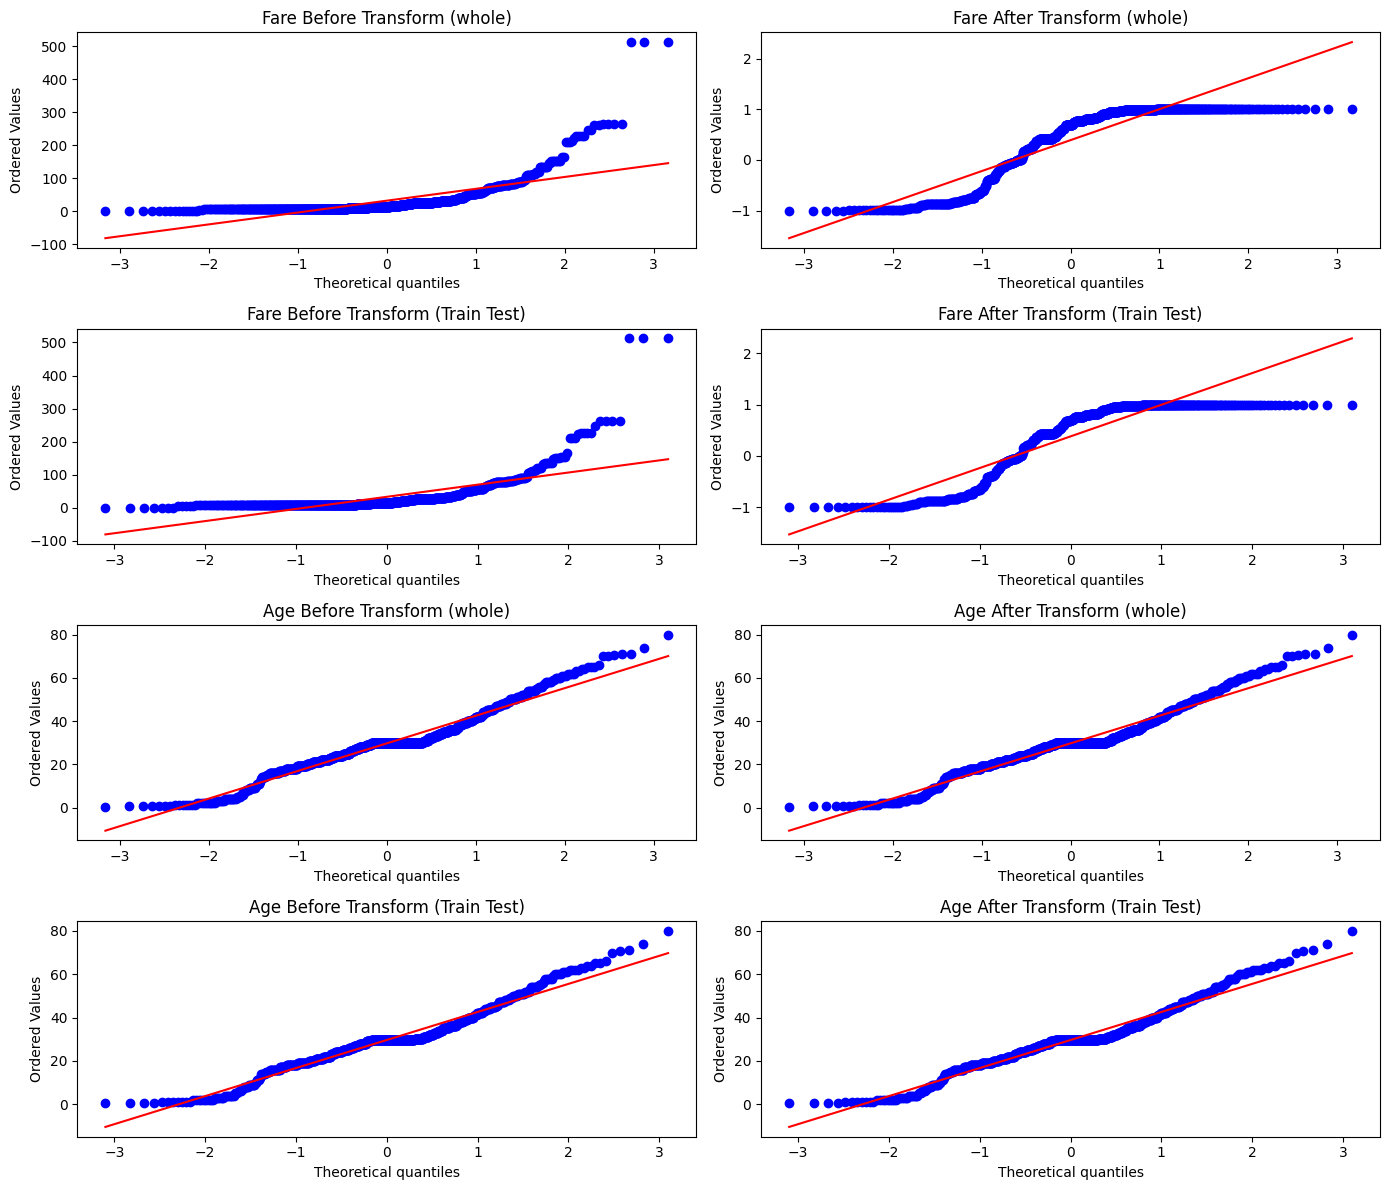

In [169]:
apply_transform(np.sin,df)